# Lab 14

By Niksh Hiremath (U20240158)

## 1. Code

### Importing libraries

In [5]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    classification_report,
)
from sklearn.svm import SVC
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras import layers, models

### Loading the dataset

In [8]:
BATCH_SIZE = 32
CLASS_NAMES = [
    "10 Note",
    "20 Note",
    "50 Note",
    "100 Note",
    "200 Note",
    "500 Note",
    "2000 Note",
]

In [9]:
all_images = []
all_labels = []

base_dir = Path.cwd() / "IndianCurrencyNotesDataset"
for label_idx, cls in enumerate(CLASS_NAMES):
    for fname in os.listdir(base_dir / cls):
        img_path = base_dir / cls / fname
        img = keras_image.load_img(img_path, target_size=(224, 224))
        img_arr = keras_image.img_to_array(img)
        all_images.append(img_arr)
        all_labels.append(label_idx)

all_images = np.array(all_images, dtype=np.float32)
all_labels = np.array(all_labels)
print(f"Total images: {len(all_images)}")

Total images: 178


### Splitting the dataset

In [10]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    all_images,
    all_labels,
    test_size=0.2,
    random_state=0,
    stratify=all_labels,
)
X_train_raw.shape, X_test_raw.shape, y_train.shape, y_test.shape

((142, 224, 224, 3), (36, 224, 224, 3), (142,), (36,))

In [11]:
# Data augmentation: random horizontal flip and rotation
augmentation = models.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
    ],
    name="augmentation",
)

X_train_aug = augmentation(X_train_raw, training=True).numpy()
X_train_pp = preprocess_input(X_train_aug)
X_test_pp = preprocess_input(X_test_raw.copy())

### Displaying sample training images

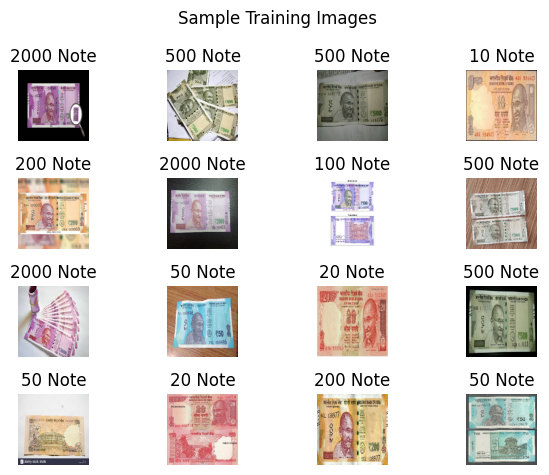

In [12]:
np.random.seed(0)
sample_idx = np.random.choice(len(X_train_raw), 16, replace=False)

fig, axes = plt.subplots(4, 4)
for ax, idx in zip(axes.flatten(), sample_idx):
    ax.imshow(X_train_raw[idx].astype(np.uint8))
    ax.set_title(CLASS_NAMES[y_train[idx]])
    ax.axis("off")

plt.suptitle("Sample Training Images")
plt.tight_layout()
plt.show()

### Loading ResNet50 and extracting features

In [13]:
resnet = ResNet50(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(224, 224, 3),
)
resnet.trainable = False
print(f"ResNet50 output dimension: {resnet.output_shape}")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step
ResNet50 output dimension: (None, 2048)


In [15]:
X_train_feat = resnet.predict(X_train_pp, batch_size=BATCH_SIZE)
X_test_feat = resnet.predict(X_test_pp, batch_size=BATCH_SIZE)

print(f"Train features shape: {X_train_feat.shape}")
print(f"Test features shape: {X_test_feat.shape}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 560ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step
Train features shape: (142, 2048)
Test features shape: (36, 2048)


### Training the SVM classifier

In [16]:
svm = SVC(kernel="rbf", C=10, gamma="scale", random_state=0)
svm.fit(X_train_feat, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### Making predictions

In [17]:
y_pred = svm.predict(X_test_feat)

### Evaluation metrics and confusion matrix

In [18]:
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy : {acc:.4f}")
print(f"F1 Score (weighted): {f1:.4f}")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

Accuracy : 0.8889
F1 Score (weighted): 0.8863
              precision    recall  f1-score   support

     10 Note       0.71      1.00      0.83         5
     20 Note       1.00      0.80      0.89         5
     50 Note       0.80      0.80      0.80         5
    100 Note       1.00      0.60      0.75         5
    200 Note       1.00      1.00      1.00         6
    500 Note       0.83      1.00      0.91         5
   2000 Note       1.00      1.00      1.00         5

    accuracy                           0.89        36
   macro avg       0.91      0.89      0.88        36
weighted avg       0.91      0.89      0.89        36



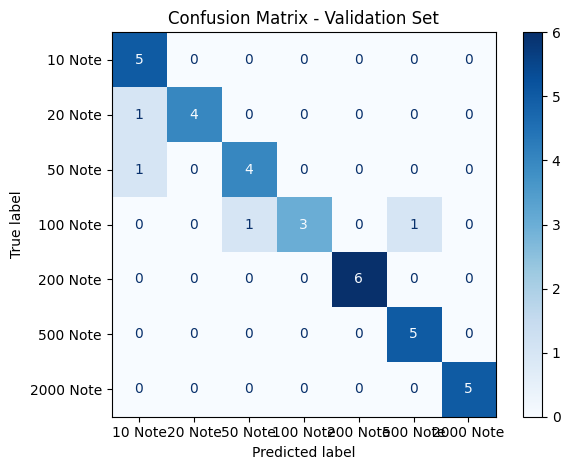

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
fig, ax = plt.subplots()
disp.plot(ax=ax, cmap="Blues", colorbar=True)

ax.set_title("Confusion Matrix - Validation Set")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
plt.tight_layout()
plt.show()

### Displaying classified images with predicted labels

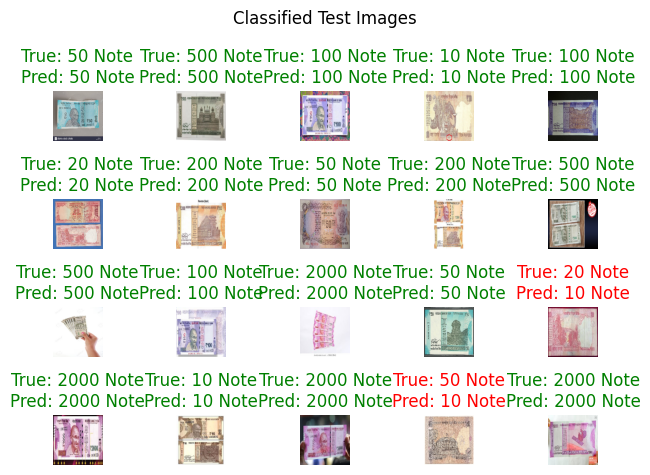

In [23]:
sample_test_idx = np.random.choice(len(X_test_raw), 20, replace=False)

fig, axes = plt.subplots(4, 5)
for ax, idx in zip(axes.flatten(), sample_test_idx):
    ax.imshow(X_test_raw[idx].astype(np.uint8))
    true_label = CLASS_NAMES[y_test[idx]]
    pred_label = CLASS_NAMES[y_pred[idx]]
    color = "green" if true_label == pred_label else "red"
    ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=color)
    ax.axis("off")

plt.suptitle("Classified Test Images")
plt.tight_layout()
plt.show()

---

## 2. Report

---

### Q1: What were the main innovations in ResNet and GoogLeNet?

**Ans:**

- **ResNet (Residual Network):** Introduced skip connections that add the input of a layer directly to its output. This allowed training of very deep networks (100+ layers) without the vanishing gradient problem during backpropagation.

- **GoogLeNet (Inception):** Introduced the Inception module, which applies multiple convolution filters of different sizes (1×1, 3×3, 5×5) in parallel on the same input and concatenates their outputs. This allowed the network to capture multi scale features efficiently while keeping computational cost low.

---

### Q2: Why do we at times need Transfer Learning?

**Ans:**

- Training a deep network from scratch requires large datasets. Transfer Learning allows us to reuse features learned from large datasets even when our own dataset is small.

- Reusing pretrained weights drastically reduces training time.

---

### Q3: How can upsampling the training set help with Transfer Learning?

**Ans:** 

- Upsampling increases the effective size and diversity of the training set. This reduces overfitting when fine tuning the pretrained model on a small target dataset.

- It also helps address class imbalance.

---

### Q4: Are there any limitations of using Transfer Learning? List only two.

**Ans:**

- If the source domain is very different from the target domain, the pretrained features may not transfer well and can even hurt performance.

- In some cases, features learned from the source task are irrelevant or misleading for the target task, causing the model to perform worse than training from scratch.

---

### Q5: What are the different approaches in Transfer Learning?

**Ans:**

- **Feature extraction:** The pretrained model is used as a fixed feature extractor. All layers are frozen and only the new classifier head is trained on the target data.

- **Fine tuning:** Some of the later layers of the pretrained network are unfrozen and retrained along with the new head on the target data.

- **Full network fine tuning:** All layers of the pretrained network are retrained on the target dataset.

---